## Basic setup

In [1]:
from pathlib import Path
example_data_path = Path("../parcels_example_data/")

## Importing relevant modules

We need to import `parcels` itself along with `matplotlib`, `xarray`, and `datetime`.

In [2]:
import parcels
from matplotlib import pyplot as plt
import xarray
import datetime

## Create fieldset

We'll let two particles in an idealised velocity field run forward for 6 days and then backward again.

Create fieldsset w/ `.from_parcels()` on the "MovingEddies_data" dataset (where individual files are called `"moving_eddies?.nc"`:

In [3]:
example_dataset_folder = parcels.download_example_dataset("MovingEddies_data")

fieldset = parcels.FieldSet.from_parcels(f"{example_dataset_folder}/moving_eddies")


Have a look:
- `fieldset.computeTimeChunk()` loads data
- plot `fieldset.U.data[0, :, :]` against its cooreds `fieldset.U.grid.lon`, and `fieldset.U.grid.lat`.

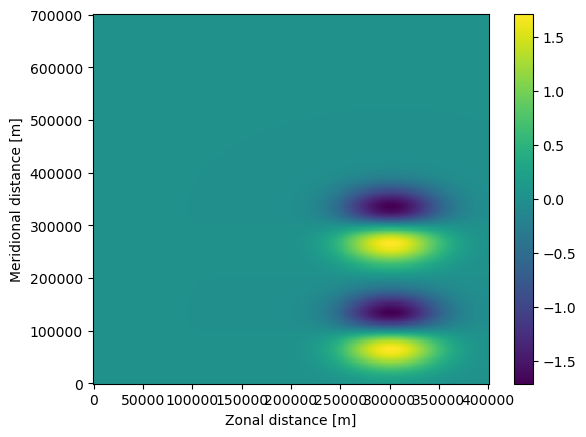

In [4]:
fieldset.computeTimeChunk()

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.colorbar()
plt.show()

## Create Particleset

Create a particleset using `ParticleSet.from_list()` starting on the `lon=3.3e5` line.

In [5]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,  # the fields on which the particles are advected
    pclass=parcels.JITParticle,  # the type of particles (JITParticle or ScipyParticle)
    lon=[3.3e5, 3.3e5],  # a vector of release longitudes
    lat=[1.5e5, 2.8e5],  # a vector of release latitudes
)

In [6]:
pset_orig = pset

Have a look at the `particleset`. (Print and plot `pset.lon` and `pset.lat` along with the `fieldset`.)

In [7]:
print(pset)

P[0](lon=330000.000000, lat=150000.000000, depth=0.000000, time=not_yet_set)
P[1](lon=330000.000000, lat=280000.000000, depth=0.000000, time=not_yet_set)


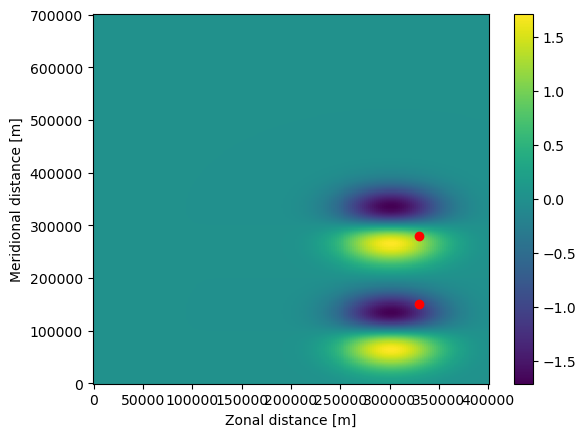

In [8]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.colorbar()
plt.plot(pset.lon, pset.lat, "ro")
plt.show()

## Execute

Let particles evolve with the `AdvectionRK4` `kernel`, using a `runtime` of 3 days with a 5 minute time step `dt`.

In [9]:
pset.execute(
    parcels.AdvectionRK4,  # the kernel (which defines how particles move)
    runtime=datetime.timedelta(days=3),  # the total length of the run
    dt=datetime.timedelta(minutes=5),  # the timestep of the kernel
)

100%|██████████| 259200.0/259200.0 [00:00<00:00, 6398957.00it/s]


Have a look at the new particle positions.

In [10]:
print(pset)

P[0](lon=308019.468750, lat=146597.250000, depth=0.000000, time=258900.000000)
P[1](lon=296370.875000, lat=298952.625000, depth=0.000000, time=258900.000000)


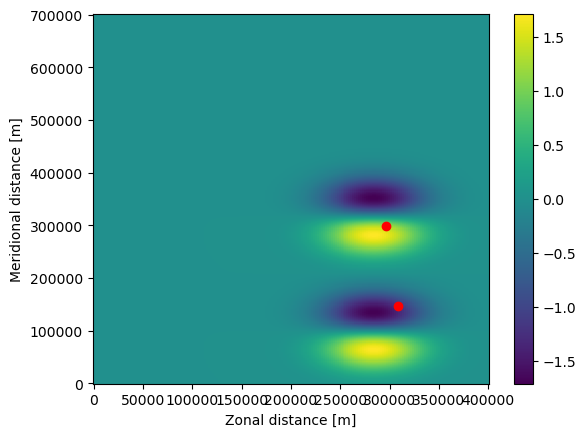

In [11]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.colorbar()
plt.plot(pset.lon, pset.lat, "ro")
plt.show()

## Write outputs

Define a `ParticleFile` (passed to `.execute()` as `output_file`) "EddyParticles.zarr" with an `outputdt` of 1 hour and execute the `particleset` again for 3 days.

In [12]:
output_file1 = pset.ParticleFile(
    name="EddyParticles.zarr",  # the file name
    outputdt=datetime.timedelta(hours=1),  # the time step of the outputs
)

print(output_file1)

In [13]:
pset.execute(
    parcels.AdvectionRK4,  # the kernel (which defines how particles move)
    runtime=datetime.timedelta(days=3),  # the total length of the run
    dt=datetime.timedelta(minutes=5),  # the timestep of the kernel
    output_file=output_file1
)
print(pset)

INFO: Output files are stored in EddyParticles.zarr.
100%|██████████| 259200.0/259200.0 [00:01<00:00, 232596.92it/s]
P[0](lon=280833.125000, lat=146932.718750, depth=0.000000, time=518100.000000)
P[1](lon=260835.125000, lat=320403.343750, depth=0.000000, time=518100.000000)


Have a look at the output file with `xarray` (using `.open_zarr()`).

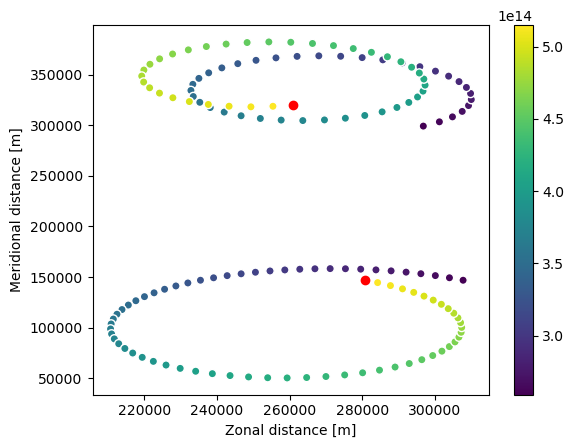

In [14]:
ds = xarray.open_zarr("EddyParticles.zarr")

ds.plot.scatter(x="lon", y="lat", hue="time")
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.plot(pset_orig.lon, pset_orig.lat,"ro")
plt.show()

## Run backwards in time

Run particles backward in time for 6 days and compare the recorded trajectories.

In [15]:
output_file2 = pset.ParticleFile(
    name="EddyParticles2.zarr",  # the file name
    outputdt=datetime.timedelta(hours=1),  # the time step of the outputs
)

In [16]:
pset.execute(
    parcels.AdvectionRK4,  # the kernel (which defines how particles move)
    runtime=datetime.timedelta(days=6),  # the total length of the run
    dt=-datetime.timedelta(minutes=5),  # the timestep of the kernel
    output_file=output_file2
)

print(pset)

INFO: Output files are stored in EddyParticles2.zarr.
100%|██████████| 518400.0/518400.0 [00:02<00:00, 226760.30it/s]
P[0](lon=329684.000000, lat=150185.390625, depth=0.000000, time=300.000000)
P[1](lon=330289.968750, lat=280418.906250, depth=0.000000, time=300.000000)


Have a look with Xarray and compare both output files

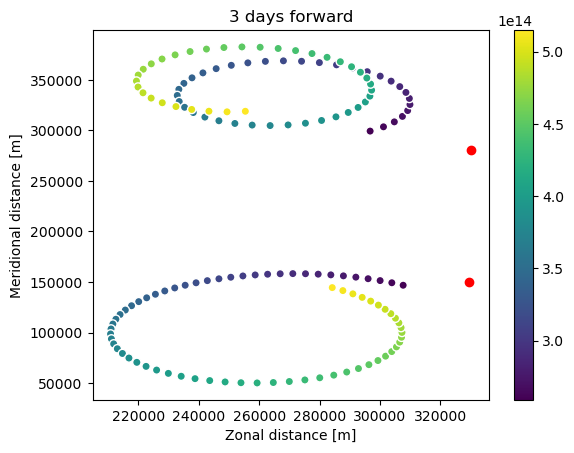

In [17]:
ds1 = xarray.open_zarr("EddyParticles.zarr")

ds1.plot.scatter(x="lon", y="lat", hue="time")
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.title("3 days forward")
plt.plot(pset_orig.lon, pset_orig.lat,"ro")
plt.show()

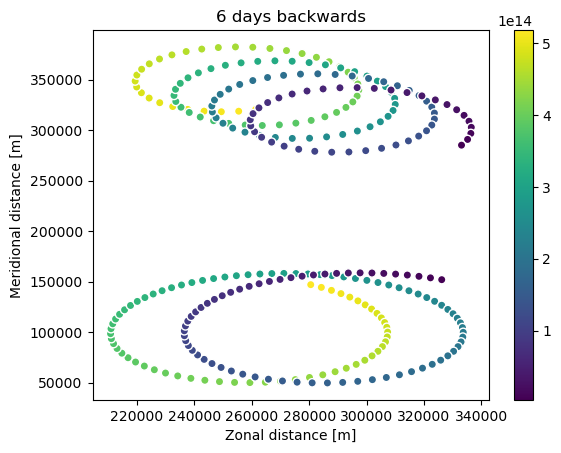

In [22]:
ds2 = xarray.open_zarr("EddyParticles2.zarr/")

ds2.plot.scatter(x="lon", y="lat", hue="time")
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.title("6 days backwards")
plt.show()

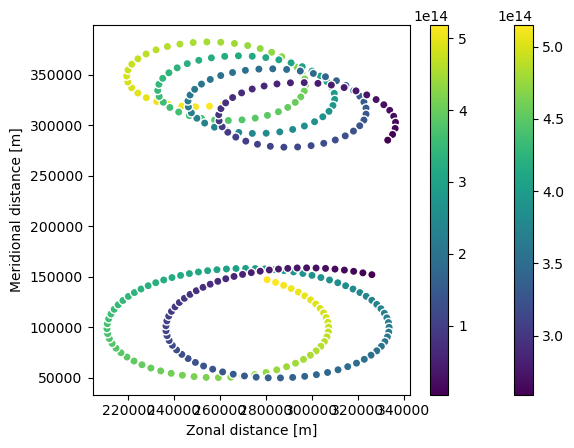

In [24]:
ds1 = xarray.open_zarr("EddyParticles.zarr/")
ds2 = xarray.open_zarr("EddyParticles2.zarr/")

ds1.plot.scatter(x="lon", y="lat", hue="time", marker="*")
ds2.plot.scatter(x="lon", y="lat", hue="time")
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.show()